# Notebook 2: What changed inside the vote distributions?

Notebook 1 answered the hypotheses. This notebook looks closer at **what** moved.

**Route:** the five kinds of change → how many texts → same emotions with new percentages →
which emotions appear or disappear → by group → humans vs models → average gain or loss per emotion
→ spread and vote counts → individual models → prompt set-ups → generic author vs specific persona
→ the H3 check for the old method.

**About the code.** The first section repeats the calculation code from Notebook 1, so this
notebook runs on its own. The code is explained in Notebook 1; you can skip it here.

As in Notebook 1, every model comparison uses only the models that answered validly on both
sides, and every percentage is shown with its count.

## Setup: the same calculation code as Notebook 1

In [1]:
# ---- Housekeeping: libraries, folders and display helpers. Nothing is calculated here. ----
from pathlib import Path
from itertools import combinations, product
import hashlib
import re
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
%matplotlib inline

# The project folder is the one that contains data/. This works whether Jupyter was started
# in the project folder or inside distribution_analysis_v1/.
ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA = ROOT / 'data'
RESULTS = ROOT / 'results'          # every table and graph below is also saved here
RESULTS.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi': 115, 'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titleweight': 'bold', 'axes.titlesize': 13,
                     'figure.figsize': (10, 5), 'savefig.bbox': 'tight'})
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 60)
pd.set_option('display.width', 150)


def explain(text):
    """Show a short explanation under a result."""
    display(Markdown(text))


def table(df, name, digits=3):
    """Save a table as results/<name>.csv and show it, rounded."""
    df.to_csv(RESULTS / (name + '.csv'), index=False)
    shown = df.round(digits).copy()
    # p-values keep 4 significant digits, so a very small p never shows as 0.
    for c in df.columns:
        if str(c).startswith('p_') or c in ['p_value', 'p_BH']:
            shown[c] = df[c].map(lambda x: f'{x:.4g}' if pd.notna(x) else '')
    display(shown)


def finish(fig, name):
    """Save a figure as results/<name>.png and show it."""
    fig.tight_layout()
    fig.savefig(RESULTS / (name + '.png'), dpi=170)
    plt.show()

In [2]:
# The 11 emotions, always in this alphabetical order. Every vote-share vector uses this order.
E = ['anger', 'disgust', 'fear', 'guilt', 'joy', 'pride',
     'relief', 'sadness', 'shame', 'surprise', 'trust']
EI = {e: i for i, e in enumerate(E)}      # emotion -> position, e.g. EI['joy'] is 4

# The three text groups: short code names and display names.
CATS = ['unambiguous', 'author_independent', 'author_relevant']
CAT_NAMES = ['Unambiguous', 'Author-independent', 'Author-relevant']
CAT_NAME = dict(zip(CATS, CAT_NAMES))
POOL_TO_KEY = {'Unambiguous': 'unambiguous',
               'Author-Independent Ambiguous': 'author_independent',
               'Author-Relevant Ambiguous': 'author_relevant'}
COLORS = {'Human': '#177e89', 'LLM': '#d66b35'}

# How many random shuffles or resamples every test and error bar uses.
N_RANDOM = 10000

# Where each model's answer is stored in experiment_results_all.csv.
MODEL_COLS = {'OpenAI': 'ChatGPT_label_norm', 'Claude': 'Claude_label_norm',
              'Gemini': 'Gemini_label_norm', 'Qwen3': 'Qwen3_label_norm',
              'Gemma3': 'Gemma3_label_norm', 'Ministral': 'Ministral_label_norm',
              'Llama31': 'Llama31_label_norm'}
MODEL_RAW_COLS = {m: col.replace('_label_norm', '_label') for m, col in MODEL_COLS.items()}

In [3]:
def vec(votes):
    """Votes -> vote shares over the 11 emotions.
    votes is a list of emotion positions: anger, anger, sadness = [0, 0, 7]
    -> 0.667 anger, 0.333 sadness, 0 for the other nine emotions."""
    return np.bincount(votes, minlength=len(E)).astype(float) / len(votes)


def entropy(v):
    """How spread out a vote-share vector is (in 'nats').
    0 = everyone chose the same emotion; bigger = votes spread over more emotions."""
    v = np.asarray(v)
    safe = np.where(v > 0, v, 1)          # log(1) = 0, so emotions with no votes add nothing
    return -(safe * np.log(safe)).sum(axis=-1)


def cosine(a, b):
    """Direction similarity of two shift vectors: +1 same direction, 0 unrelated, -1 opposite.
    It is undefined (NaN) when either vector is all zeros, i.e. that side did not move."""
    lengths = np.linalg.norm(a, axis=-1) * np.linalg.norm(b, axis=-1)
    return np.divide((a * b).sum(axis=-1), lengths,
                     out=np.full_like(lengths, np.nan, dtype=float), where=lengths > 1e-12)


def compare_votes(a, b):
    """Compare the NEUTRAL votes a with the PERSONA votes b for one text.
    Returns every quantity the notebooks use for that one comparison."""
    p, q = vec(a), vec(b)                  # neutral shares, persona shares
    ps, qs = p > 0, q > 0                  # which emotions received at least one vote
    tp, tq = p == p.max(), q == q.max()    # the top emotion(s); more than one means a tie

    tv = np.abs(q - p).sum() / 2           # SHIFT (total variation): share of votes that must move
    gain = qs & ~ps                        # emotions that APPEAR under the persona
    loss = ps & ~qs                        # emotions that DISAPPEAR under the persona
    same_support = np.array_equal(ps, qs)  # exactly the same emotions present on both sides?
    same_top = np.array_equal(tp, tq)      # exactly the same top emotion(s) on both sides?

    # OLD METHOD: the selected label is the top emotion; a tie goes to the alphabetically first.
    w0, w1 = int(np.argmax(p)), int(np.argmax(q))
    # The same, but with ties broken by reverse alphabet (used to show that the tie rule matters).
    wr0 = len(E) - 1 - int(np.argmax(p[::-1]))
    wr1 = len(E) - 1 - int(np.argmax(q[::-1]))

    # The five kinds of change. Every comparison gets exactly one.
    if tv < 1e-12:
        change = 'No distribution change'
    elif same_support:
        change = 'Same emotions; proportions change'
    elif gain.any() and loss.any():
        change = 'Emotions appear AND disappear'
    elif gain.any():
        change = 'Emotions appear only'
    else:
        change = 'Emotions disappear only'

    moved = tv > 1e-12
    return dict(p=p, q=q, delta=q - p, neutral_votes=a, persona_votes=b,
                neutral_n=len(a), persona_n=len(b), winner0=w0, winner1=w1,
                flip=float(w0 != w1),                  # old method: did the label change?
                flip_reverse=float(wr0 != wr1), tv=tv,
                neutral_tie=tp.sum() > 1, persona_tie=tq.sum() > 1,
                same_top=same_top, same_support=same_support, gained=gain, lost=loss,
                gain_any=bool(gain.any()), loss_any=bool(loss.any()),
                n_gained=int(gain.sum()), n_lost=int(loss.sum()),
                same_support_change=bool(same_support and moved),
                hidden_label=bool(w0 == w1 and moved),         # moved, but same selected label
                hidden_top=bool(same_top and moved),           # moved, but same top emotion(s)
                strict_proportion=bool(same_top and same_support and moved),
                entropy_change=float(entropy(q) - entropy(p)), change=change)

In [4]:
# Some model answers were stored only in raw form (e.g. '5. joy', '**joy**' or just '5').
# This turns them into a plain emotion name. It is only used where the cleaned column is blank.
_NUMBERED = re.compile(r'^\s*(\d{1,2})\s*[.\):]\s*(.+?)\s*$')
_BARE_NUMBER = re.compile(r'^\s*(\d{1,2})\s*[.\):]?\s*$')


def clean_model_answer(raw):
    if pd.isna(raw):
        return raw
    s = str(raw).strip().strip('*').strip()
    m = _BARE_NUMBER.match(s)
    if m:                                   # just a number: the n-th emotion in the list
        idx = int(m.group(1))
        return E[idx - 1] if 1 <= idx <= len(E) else s.lower()
    m = _NUMBERED.match(s)
    if m:                                   # '5. joy' -> 'joy'
        s = m.group(2).strip('*').strip()
    return s.lower()


def original_corpus_shares(ids):
    """Vote shares of the 5 ORIGINAL corpus readers per text (no persona).
    Votes outside the 11 emotions (no-emotion, boredom) are left out."""
    votes = pd.read_csv(DATA / 'corpus' / 'crowd-enVent_validation.tsv', sep='\t',
                        usecols=['text_id', 'emotion'])
    votes['text_id'] = votes.text_id.astype(str)
    votes = votes[votes.text_id.isin(set(ids))]
    shares = {}
    for tid, g in votes.groupby('text_id'):
        cleaned = [v.strip().lower() for v in g.emotion.astype(str) if v.strip() != '']
        valid = [v for v in cleaned if v in EI]
        shares[tid] = (np.array([valid.count(e) / len(valid) for e in E]) if valid
                       else np.full(len(E), np.nan))
    return shares


class Study:
    """Loads every vote once and builds all neutral-vs-persona comparisons."""

    def __init__(self):
        # 1. The 300 sampled texts and their group.
        self.master = pd.read_csv(DATA / 'sampled_texts.csv')
        self.master['text_id'] = self.master.text_id.astype(str)
        assert self.master.text_id.is_unique and len(self.master) == 300
        self.ids = sorted(self.master.text_id, key=int)
        by_id = self.master.set_index('text_id')
        self.category = by_id.classification.map(POOL_TO_KEY).to_dict()
        assert pd.Series(self.category).value_counts().reindex(CATS).eq(100).all()
        self.text = by_id.text.to_dict()

        # 2. Human votes: one row per text and condition, votes stored like 'joy|joy|pride'.
        self.human_raw = pd.read_csv(DATA / 'human_annotations.csv')
        self.human_raw['text_id'] = self.human_raw.text_id.astype(str)
        assert not self.human_raw.duplicated(['text_id', 'side']).any()
        self.hvotes, self.personas = {}, {}
        for _, r in self.human_raw.iterrows():
            labels = [x.strip().lower() for x in str(r.raters_raw).split('|')]
            self.hvotes[(r.text_id, r.side)] = np.array([EI[x] for x in labels if x in EI])
            self.personas[(r.text_id, r.side)] = str(r.persona)
        assert len(self.hvotes) == 900 and all(len(v) >= 3 for v in self.hvotes.values())
        assert set(self.hvotes) == set(product(self.ids, ['neutral', 'a', 'b']))

        # 3. Model answers: 7,200 rows = 300 texts x 4 framings x 6 prompt set-ups; 7 models per row.
        raw = pd.read_csv(DATA / 'experiment_results_all.csv')
        raw['text_id'] = raw.text_id.astype(str)
        keys = ['text_id', 'framing_condition', 'prompt_variant', 'label_format']
        assert len(raw) == 7200 and not raw.duplicated(keys).any()
        self.configs = sorted(set(zip(raw.prompt_variant, raw.label_format)))
        assert len(self.configs) == 6
        self.mvotes = {}
        for _, r in raw.iterrows():
            votes = {}
            for model, col in MODEL_COLS.items():
                answer = r[col]
                if pd.isna(answer) or not str(answer).strip():
                    answer = clean_model_answer(r[MODEL_RAW_COLS[model]])
                answer = str(answer).strip().lower()
                if answer in EI:                # answers outside the 11 emotions are left out
                    votes[model] = EI[answer]
            self.mvotes[(r.text_id, r.framing_condition, r.prompt_variant, r.label_format)] = votes
        assert set(self.mvotes) == {(tid, fr, pv, lf) for tid in self.ids
                                    for fr in ['neutral', 'generic_human', 'persona_a', 'persona_b']
                                    for pv, lf in self.configs}

        # 4. Build every comparison: one text, neutral vs ONE persona.
        #    Humans: 300 texts x 2 personas = 600. Models: also x 6 prompt set-ups = 3,600.
        #    For models, only models with a valid answer on BOTH sides are used.
        h, l, individual = [], [], []
        for tid in self.ids:
            for side in ['a', 'b']:
                h.append(dict(text_id=tid, category=self.category[tid], source='Human', side=side,
                              **compare_votes(self.hvotes[(tid, 'neutral')], self.hvotes[(tid, side)])))
                for pv, lf in self.configs:
                    n = self.mvotes[(tid, 'neutral', pv, lf)]
                    p = self.mvotes[(tid, 'persona_' + side, pv, lf)]
                    common = sorted(n.keys() & p.keys())
                    assert len(common) >= 3
                    a = np.array([n[m] for m in common])
                    b = np.array([p[m] for m in common])
                    l.append(dict(text_id=tid, category=self.category[tid], source='LLM', side=side,
                                  config=pv + '/' + lf, models='|'.join(common), **compare_votes(a, b)))
                    individual.extend(dict(text_id=tid, category=self.category[tid], side=side,
                                           config=pv + '/' + lf, model=m, changed=int(n[m] != p[m]))
                                      for m in common)
        self.h = pd.DataFrame(h)                      # the 600 human comparisons
        self.l = pd.DataFrame(l)                      # the 3,600 model comparisons
        self.individual = pd.DataFrame(individual)    # every single model's answer pair
        self.cells = pd.concat([self.h, self.l], ignore_index=True)
        assert len(self.h) == 600 and len(self.l) == 3600
        assert self.l.groupby(['text_id', 'side']).size().eq(6).all()

        # 5. The original corpus readers (used for the before-persona comparison).
        self.original = original_corpus_shares(self.ids)
        self.null_cache, self.test_cache = {}, {}
        audit = self.cells.drop(columns=['p', 'q', 'delta', 'neutral_votes', 'persona_votes',
                                         'gained', 'lost'])
        audit.to_csv(RESULTS / 'comparison_audit.csv', index=False)


def record_hashes():
    """Fingerprint every input file (results/input_sha256.csv) to prove the data were not changed."""
    rows = []
    for p in sorted(DATA.rglob('*')):
        if p.is_file():
            rows.append(dict(file=str(p.relative_to(ROOT)),
                             sha256=hashlib.sha256(p.read_bytes()).hexdigest()))
    pd.DataFrame(rows).to_csv(RESULTS / 'input_sha256.csv', index=False)


def design_overview(study):
    rows = []
    for src, d in [('Human', study.h), ('LLM', study.l)]:
        rows.append(dict(source=src, texts=d.text_id.nunique(), neutral_persona_comparisons=len(d),
                         observations_per_text=2 if src == 'Human' else 12,
                         minimum_votes=int(min(d.neutral_n.min(), d.persona_n.min())),
                         maximum_votes=int(max(d.neutral_n.max(), d.persona_n.max()))))
    return pd.DataFrame(rows)

In [5]:
def boot_mean(x, seed=42, n=N_RANDOM):
    """Mean plus a 95% error bar. The error bar: redraw the list of values (one per TEXT) with
    replacement 10,000 times, recompute the mean each time, keep the middle 95%."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if not len(x):
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    means = x[rng.integers(0, len(x), (n, len(x)))].mean(axis=1)
    return float(x.mean()), *np.quantile(means, [.025, .975])


def summary(study, metric, by_category=True):
    """Average of a measure, first per text (so each text counts once), then over texts."""
    groups = ['source'] + (['category'] if by_category else [])
    rows = []
    for key, g in study.cells.groupby(groups, sort=False):
        key = key if isinstance(key, tuple) else (key,)
        per_text = g.groupby('text_id')[metric].mean().to_numpy(float)
        mean, lo, hi = boot_mean(per_text)
        rows.append(dict(zip(groups, key)) | dict(comparisons=len(g), texts=len(per_text),
                                                  value_pct=100 * mean, lo_pct=100 * lo, hi_pct=100 * hi))
    return pd.DataFrame(rows)


def bar(study, metric, name, title, ylabel):
    """Bar chart of summary() by group, humans next to models, with 95% error bars."""
    d = summary(study, metric)
    fig, ax = plt.subplots(figsize=(10, 5))
    for j, src in enumerate(['Human', 'LLM']):
        q = d[d.source == src].set_index('category').reindex(CATS)
        x = np.arange(3) + (j - .5) * .35
        ax.bar(x, q.value_pct, .33, label=src, color=COLORS[src])
        ax.errorbar(x, q.value_pct, yerr=[q.value_pct - q.lo_pct, q.hi_pct - q.value_pct],
                    fmt='none', color='#303030', capsize=4)
        for xx, yy in zip(x, q.value_pct):
            ax.text(xx, yy + 1.5, f'{yy:.1f}%', ha='center', fontsize=10)
    ax.set_xticks(range(3), CAT_NAMES)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.set_ylim(0, min(110, max(d.hi_pct) * 1.22 + 3))
    finish(fig, name)
    table(d, name)
    return d

In [6]:
def chance_shuffles(study, source, index):
    """For ONE comparison, list every way the votes could have come out if the persona did nothing.
    Humans (different people per version): pool the neutral and persona votes, then try every way
      of splitting them back into two groups of the original sizes (3 + 3 votes = 20 ways).
    Models (the same model answered both versions): each model's own two answers are either kept
      or swapped, giving 2 x 2 x ... possibilities (128 for 7 models).
    Returns, for every possibility, whether the label changed and how big the shift is."""
    key = (source, index)
    if key in study.null_cache:
        return study.null_cache[key]
    r = (study.h if source == 'Human' else study.l).iloc[index]
    a, b = r.neutral_votes, r.persona_votes
    if source == 'Human':
        pool = np.concatenate([a, b])
        n = len(a)
        total = np.bincount(pool, minlength=len(E))
        counts = np.array([np.bincount(pool[list(c)], minlength=len(E))
                           for c in combinations(range(len(pool)), n)])
        pa = counts / n
        pb = (total - counts) / len(b)
    else:
        swaps = np.array(list(product([False, True], repeat=len(a))))
        av = np.where(swaps, b, a)
        bv = np.where(swaps, a, b)
        pa = np.eye(len(E))[av].mean(axis=1)
        pb = np.eye(len(E))[bv].mean(axis=1)
    result = {'flip': (pa.argmax(axis=1) != pb.argmax(axis=1)).astype(float),
              'tv': np.abs(pa - pb).sum(axis=1) / 2}
    study.null_cache[key] = result
    return result


def holm_correct(pvals):
    """Holm correction: sort the p-values, multiply the smallest by the number of tests, the next
    by one less, and so on; never let an adjusted value drop below the one before it; cap at 1."""
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(n)
    running_max = 0.0
    for rank, idx in enumerate(order):
        val = min((n - rank) * pvals[idx], 1.0)
        running_max = max(running_max, val)
        adj[idx] = running_max
    return adj


def test_h1_h2(study, metric):
    """H1 (humans: 3 groups x 2 personas = 6 tests) and H2 (models: 2 personas = 2 tests).
    metric is 'flip' (old method: did the label change?) or 'tv' (vector method: shift size).
    For each test:
      1. observed = average of the metric over the comparisons in that group;
      2. chance = 10,000 times, give every comparison one random outcome from chance_shuffles()
         and average them -> 10,000 averages that could happen if the persona did nothing;
      3. p = share of those chance averages that are at least as big as the observed one."""
    if metric in study.test_cache:
        return study.test_cache[metric].copy()
    rows = []
    for source, d in [('Human', study.h), ('LLM', study.l)]:
        for side in ['a', 'b']:
            for cat in (CATS if source == 'Human' else ['all']):
                sub = d[(d.side == side) & ((d.category == cat) if cat != 'all' else True)]
                rng = np.random.default_rng(4200 + len(rows))
                null = np.zeros(N_RANDOM)
                expect = 0
                for index in sub.index:
                    values = chance_shuffles(study, source, index)[metric]
                    null += values[rng.integers(0, len(values), N_RANDOM)]
                    expect += values.mean()
                null /= len(sub)
                expect /= len(sub)
                obs = sub[metric].mean()
                p = (1 + np.count_nonzero(null >= obs - 1e-12)) / (N_RANDOM + 1)
                mean, lo, hi = boot_mean(sub.groupby('text_id')[metric].mean())
                rows.append(dict(hypothesis='H1' if source == 'Human' else 'H2', source=source,
                                 side=side, category=cat, n_cells=len(sub), observed_pct=100 * obs,
                                 conditional_null_pct=100 * expect, excess_pp=100 * (obs - expect),
                                 ci_lo=100 * lo, ci_hi=100 * hi, p_raw=p))
    out = pd.DataFrame(rows)
    out['p_holm'] = np.nan
    for h in ['H1', 'H2']:                 # correct H1's 6 tests together, H2's 2 tests together
        use = out.hypothesis == h
        out.loc[use, 'p_holm'] = holm_correct(out.loc[use, 'p_raw'])
    out['reject_05'] = out.p_holm < .05
    study.test_cache[metric] = out
    return out.copy()


def plot_h1_h2(study, metric, name):
    """Dot = observed value with 95% error bar; x = what chance alone gives; label = Holm p."""
    d = test_h1_h2(study, metric)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [2, 1]})
    for ax, h in zip(axes, ['H1', 'H2']):
        q = d[d.hypothesis == h].reset_index(drop=True)
        y = np.arange(len(q))
        ax.errorbar(q.observed_pct, y, xerr=[q.observed_pct - q.ci_lo, q.ci_hi - q.observed_pct],
                    fmt='o', color='#177e89', capsize=3, label='Observed; 95% text CI')
        ax.scatter(q.conditional_null_pct, y, marker='x', color='#d66b35', label='Conditional-null mean')
        ax.set_yticks(y, [('All texts' if r.category == 'all' else CAT_NAME[r.category]) + ' / '
                          + r.side.upper() for _, r in q.iterrows()])
        for i, r in q.iterrows():
            ax.annotate(f'p={r.p_holm:.4f}', (r.observed_pct, i), xytext=(0, 10),
                        textcoords='offset points', fontsize=8)
        ax.set_xlim(0, 100)
        ax.set_title(h + ': ' + ('one-label changes' if metric == 'flip' else 'distribution distances'))
        ax.set_xlabel('Changed comparisons (%)' if metric == 'flip' else 'TV × 100')
        ax.set_ylim(-.7, len(q) - .3)
    axes[0].legend(fontsize=8, loc='lower left')
    finish(fig, name)
    table(d, name)
    return d

In [7]:
def test_h3(study, metric):
    """H3: do author-relevant texts change more than author-independent ones (humans)?
    Each text gets one number = its average over the two personas.
    'Raw' compares those numbers directly.
    'Conditional-null referenced' first subtracts what chance alone would give for that same
      text (the average of chance_shuffles), then compares what is left (the 'excess').
    p-value: shuffle which group each text belongs to 10,000 times and see how often the
      difference between the group averages is at least as big as the real one (either sign).
    Error bar: resample the texts within each group 10,000 times."""
    d = study.h.copy()
    d['expected'] = [chance_shuffles(study, 'Human', i)[metric].mean() for i in d.index]
    d['excess'] = d[metric] - d.expected
    t = d.groupby(['text_id', 'category'])[[metric, 'expected', 'excess']].mean().reset_index()
    rows = []
    for mode, col in [('Raw', metric), ('Conditional-null referenced', 'excess')]:
        for a, b in [('author_relevant', 'author_independent'), ('author_independent', 'unambiguous'),
                     ('author_relevant', 'unambiguous')]:
            x = t.loc[t.category == a, col].to_numpy()
            y = t.loc[t.category == b, col].to_numpy()
            obs = x.mean() - y.mean()
            rng = np.random.default_rng(102 + len(rows))
            pooled = np.r_[x, y]
            indices = np.argsort(rng.random((N_RANDOM, len(pooled))), axis=1)
            perms = pooled[indices]
            null = perms[:, :len(x)].mean(axis=1) - perms[:, len(x):].mean(axis=1)
            p = (1 + (np.abs(null) >= abs(obs) - 1e-12).sum()) / (N_RANDOM + 1)
            boots = (x[rng.integers(0, len(x), (N_RANDOM, len(x)))].mean(axis=1)
                     - y[rng.integers(0, len(y), (N_RANDOM, len(y)))].mean(axis=1))
            lo, hi = np.quantile(boots, [.025, .975])
            rows.append(dict(analysis=mode, contrast=CAT_NAME[a] + ' minus ' + CAT_NAME[b],
                             difference_pp=100 * obs, ci_lo=100 * lo, ci_hi=100 * hi, p_raw=p))
    out = pd.DataFrame(rows)
    out['p_holm'] = np.nan
    for mode in out.analysis.unique():     # Holm over the 3 contrasts, separately per analysis
        use = out.analysis == mode
        out.loc[use, 'p_holm'] = holm_correct(out.loc[use, 'p_raw'])
    return out, t

In [8]:
EVENT_TYPES = ['No distribution change', 'Same emotions; proportions change', 'Emotions appear only',
               'Emotions disappear only', 'Emotions appear AND disappear']


def events(study):
    """Count the five kinds of change, per source."""
    rows = []
    for src, d in [('Human', study.h), ('LLM', study.l)]:
        for change in EVENT_TYPES:
            flag = d.change == change
            rows.append(dict(source=src, event=change, comparisons=int(flag.sum()), denominator=len(d),
                             percent=100 * flag.mean(),
                             texts_with_event=int(d.loc[flag, 'text_id'].nunique()), text_denominator=300))
    return pd.DataFrame(rows)


def events_plot(study):
    d = events(study)
    fig, ax = plt.subplots(figsize=(11, 5))
    names = d.event.drop_duplicates().tolist()
    y = np.arange(len(names))
    for j, src in enumerate(['Human', 'LLM']):
        q = d[d.source == src]
        ax.barh(y + (j - .5) * .36, q.percent, .34, label=src, color=COLORS[src])
        for yy, (_, r) in zip(y + (j - .5) * .36, q.iterrows()):
            ax.text(r.percent + .5, yy, f'{r.percent:.1f}% ({r.comparisons:,}/{r.denominator:,})',
                    va='center', fontsize=9)
    ax.set_yticks(y, names)
    ax.invert_yaxis()
    ax.set_xlim(0, min(100, d.percent.max() + 26))
    ax.set_xlabel('Share of neutral–persona comparisons (%)')
    ax.set_title('What changed inside the distribution?')
    ax.legend()
    finish(fig, 'vector_change_types')
    table(d, 'vector_change_types')
    return d

In [9]:
def example(study, event, source, name):
    """Plot the comparison with the LARGEST shift among those that match `event`.
    Chosen because it is the clearest illustration, not because it is typical."""
    d = study.h if source == 'Human' else study.l
    choose = d[d[event]].sort_values(['tv', 'text_id'], ascending=[False, True])
    if choose.empty:
        explain(f'No {source} comparison meets this definition.')
        return
    r = choose.iloc[0]
    p, q = r.p, r.q
    active = np.flatnonzero((p + q) > 0)
    x = np.arange(len(active))
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.bar(x - .18, p[active] * 100, .35, label='Neutral', color='#586f7c')
    ax.bar(x + .18, q[active] * 100, .35, label='Persona', color=COLORS[source])
    for xx, pp, qq in zip(x, p[active] * 100, q[active] * 100):
        ax.text(xx - .18, pp + 1, f'{pp:.0f}%', ha='center', fontsize=9)
        ax.text(xx + .18, qq + 1, f'{qq:.0f}%', ha='center', fontsize=9)
    ax.set_xticks(x, [E[i] for i in active])
    ax.set_ylim(0, 110)
    ax.set_ylabel('Vote share (%)')
    ax.legend()
    ax.set_title(f'{source}, text {r.text_id}, persona {r.side.upper()} — TV {r.tv * 100:.1f}%')
    finish(fig, name)
    explain(f'**Text:** {study.text[r.text_id]}\n\n**Persona:** {study.personas[(r.text_id, r.side)]}\n\n'
            f'**Winning label:** {E[r.winner0]} → {E[r.winner1]}. **Votes:** {r.neutral_n} → {r.persona_n}. '
            f'**Emotions added:** {", ".join(np.array(E)[r.gained]) or "none"}; '
            f'**removed:** {", ".join(np.array(E)[r.lost]) or "none"}. '
            + (f'**Prompt set-up:** {r.config}. ' if source == 'LLM' else '')
            + 'This is the example with the largest shift of its kind, chosen to illustrate, not to be typical.')

Two more pieces of code are used only in this notebook: which emotions appear or disappear
(`emotion_events`) with the Benjamini-Hochberg correction for many tests (`bh_fdr`), and the
equal-vote-count check (`count_sensitivity`) with the prompt test (`prompt_test`).

In [10]:
def emotion_events(study):
    """For each emotion: how often it appears (0 votes -> some) or disappears (some -> 0)."""
    rows = []
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    for ax, (src, d) in zip(axes, [('Human', study.h), ('LLM', study.l)]):
        gained = np.stack(d.gained).mean(axis=0) * 100
        lost = np.stack(d.lost).mean(axis=0) * 100
        y = np.arange(11)
        ax.barh(y - .18, gained, .35, color='#177e89', label='Appears (zero → positive)')
        ax.barh(y + .18, lost, .35, color='#d66b35', label='Disappears (positive → zero)')
        ax.set_yticks(y, E)
        ax.invert_yaxis()
        ax.set_title(src)
        ax.set_xlabel('Comparisons (%)')
        ax.legend(fontsize=8)
        for e, g, l in zip(E, gained, lost):
            rows.append(dict(source=src, emotion=e, appears_pct=g, disappears_pct=l))
    finish(fig, 'emotion_appearance_disappearance')
    out = pd.DataFrame(rows)
    table(out, 'emotion_appearance_disappearance')
    return out


def bh_fdr(pvals):
    """Benjamini-Hochberg correction for many exploratory tests: sort the p-values; the k-th
    smallest is multiplied by (number of tests / k); keep the running minimum from the top; cap at 1."""
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(n)
    running_min = 1.0
    for rank in range(n - 1, -1, -1):
        idx = order[rank]
        val = min(pvals[idx] * n / (rank + 1), 1.0)
        running_min = min(running_min, val)
        adj[idx] = running_min
    return adj

In [11]:
def count_sensitivity(study, draws=200):
    """Give both sides the same number of votes: 3 randomly chosen human votes per version, and
    the SAME 3 randomly chosen models on both sides of a model comparison. Repeat 200 times and
    average the shift and the spread change."""
    rng = np.random.default_rng(42)
    rows = []
    for src, d in [('Human', study.h), ('LLM', study.l)]:
        for _, r in d.iterrows():
            a, b = r.neutral_votes, r.persona_votes
            ia = np.argsort(rng.random((draws, len(a))), axis=1)[:, :3]
            ib = np.argsort(rng.random((draws, len(b))), axis=1)[:, :3] if src == 'Human' else ia
            p = np.eye(11)[a[ia]].mean(axis=1)
            q = np.eye(11)[b[ib]].mean(axis=1)
            rows.append(dict(source=src, text_id=r.text_id, category=r.category,
                             tv_raw=r.tv, tv_standardised=np.abs(q - p).sum(axis=1).mean() / 2,
                             entropy_raw=r.entropy_change,
                             entropy_standardised=(entropy(q) - entropy(p)).mean()))
    out = pd.DataFrame(rows)
    summary_rows = []
    for src, g in out.groupby('source', sort=False):
        for col in ['tv_raw', 'tv_standardised', 'entropy_raw', 'entropy_standardised']:
            point, lo, hi = boot_mean(g.groupby('text_id')[col].mean())
            summary_rows.append(dict(source=src, quantity=col, mean=point, ci_lo=lo, ci_hi=hi))
    return out, pd.DataFrame(summary_rows)


def prompt_test(study, metric):
    """Friedman test: within each text, rank the 6 prompt set-ups by the metric; if prompt format
    did not matter, every set-up would get similar average ranks."""
    d = study.l.groupby(['text_id', 'config'])[metric].mean().unstack('config').reindex(study.ids)
    stat, p = stats.friedmanchisquare(*[d[c] for c in d])
    return d, pd.DataFrame([dict(metric=metric, texts=300, configurations=6, friedman_stat=stat, p_value=p)])

In [12]:
study = Study()
record_hashes()
table(design_overview(study), 'design_overview')

,source,texts,neutral_persona_comparisons,observations_per_text,minimum_votes,maximum_votes
0,Human,300,600,2,3,7
1,LLM,300,3600,12,4,7


## 1. How many comparisons show each kind of change?

The five kinds are exclusive: no change; same emotions with different percentages; emotions appear
only; emotions disappear only; both. A **comparison** is one text, neutral vs one persona (and, for
models, one prompt set-up).

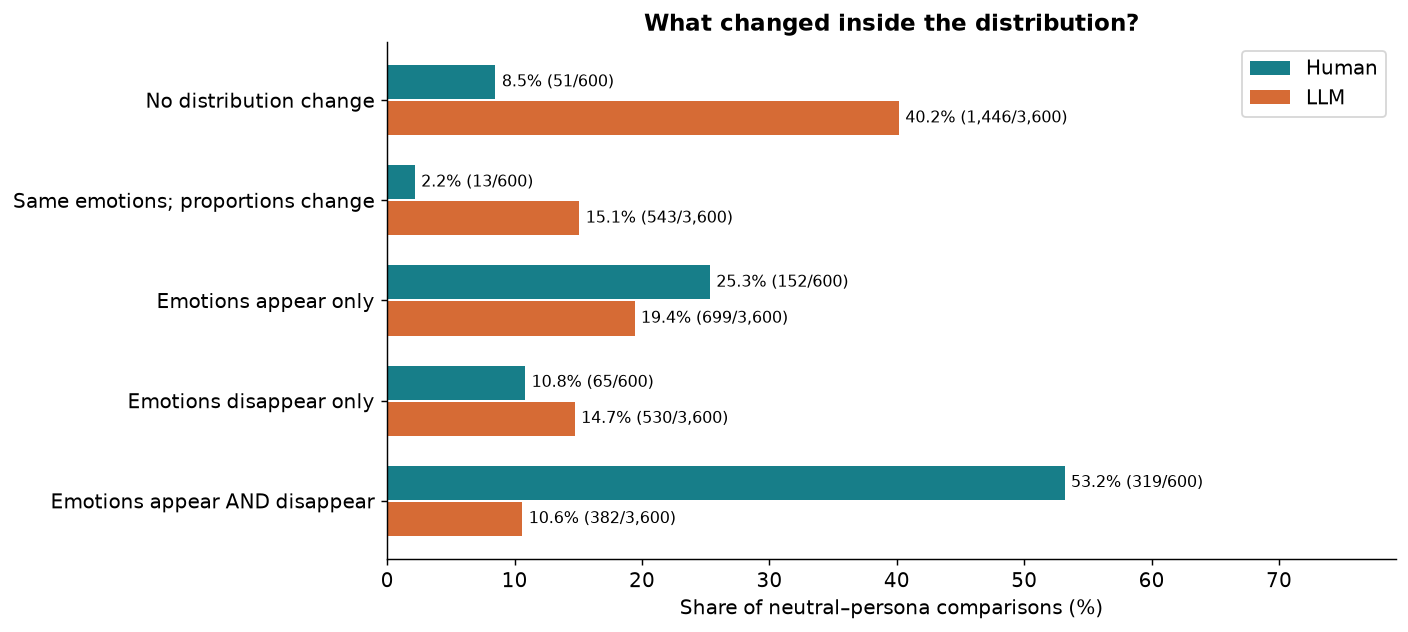

,source,event,comparisons,denominator,percent,texts_with_event,text_denominator
0,Human,No distribution change,51,600,8.500,44,300
1,Human,Same emotions; proportions change,13,600,2.167,13,300
2,Human,Emotions appear only,152,600,25.333,114,300
3,Human,Emotions disappear only,65,600,10.833,57,300
4,Human,Emotions appear AND disappear,319,600,53.167,211,300
5,LLM,No distribution change,1446,3600,40.167,245,300
6,LLM,Same emotions; proportions change,543,3600,15.083,153,300
7,LLM,Emotions appear only,699,3600,19.417,197,300
8,LLM,Emotions disappear only,530,3600,14.722,173,300
9,LLM,Emotions appear AND disappear,382,3600,10.611,112,300


**Read the plot:** bars give percentages; the fractions give exact counts. A new emotion does not have to become the winner. Models have more comparisons per text (12 vs 2), not more texts.

In [13]:
event_counts = events_plot(study)
assert event_counts.groupby('source').percent.sum().round(8).eq(100).all()
explain('**Read the plot:** bars give percentages; the fractions give exact counts. A new emotion does not '
        'have to become the winner. Models have more comparisons per text (12 vs 2), not more texts.')

## 2. In how many different texts does each event happen?

"Text incidence" = the event happens in at least one comparison of that text. One text can show
several events, so these counts overlap and must not be added up. People have 2 chances per text
and models 12, so the second table also counts model texts within each prompt set-up (2 chances
per text).

In [14]:
rows = []
for src, d in [('Human', study.h), ('LLM', study.l)]:
    for event in ['gain_any', 'loss_any', 'same_support_change', 'hidden_top', 'strict_proportion']:
        for cat in CATS:
            q = d[d.category == cat]
            any_text = q.groupby('text_id')[event].any()
            rows.append({'source': src, 'category': CAT_NAME[cat], 'event': event,
                         'texts_any_event': int(any_text.sum()), 'text_denominator': 100,
                         'comparisons_with_event': int(q[event].sum()), 'comparison_denominator': len(q),
                         'opportunities_per_text': 2 if src == 'Human' else 12})
incidence = pd.DataFrame(rows)
table(incidence, 'event_text_incidence')
config_incidence = []
for config, d in study.l.groupby('config'):
    for event in ['gain_any', 'loss_any', 'same_support_change', 'hidden_top', 'strict_proportion']:
        config_incidence.append({'configuration': config, 'event': event,
                                 'texts_with_event': int(d.groupby('text_id')[event].any().sum()), 'out_of': 300})
config_incidence = pd.DataFrame(config_incidence)
table(config_incidence, 'model_event_text_incidence_by_config')
table(config_incidence.groupby('event').texts_with_event.agg(['mean', 'min', 'max']).reset_index(),
      'model_event_incidence_config_summary', 2)
explain('**Event names:** gain_any = at least one emotion appears; loss_any = at least one disappears; '
        'same_support_change = same emotions, different percentages; hidden_top = same top emotion(s) but '
        'the votes moved; strict_proportion = same emotions AND same top, only the percentages changed.')

,source,category,event,texts_any_event,text_denominator,comparisons_with_event,comparison_denominator,opportunities_per_text
0,Human,Unambiguous,gain_any,90,100,140,200,2
1,Human,Author-independent,gain_any,95,100,163,200,2
2,Human,Author-relevant,gain_any,97,100,168,200,2
3,Human,Unambiguous,loss_any,65,100,105,200,2
4,Human,Author-independent,loss_any,79,100,133,200,2
5,Human,Author-relevant,loss_any,86,100,146,200,2
6,Human,Unambiguous,same_support_change,3,100,3,200,2
7,Human,Author-independent,same_support_change,5,100,5,200,2
8,Human,Author-relevant,same_support_change,5,100,5,200,2
9,Human,Unambiguous,hidden_top,50,100,66,200,2


,configuration,event,texts_with_event,out_of
0,few_shot/inline,gain_any,132,300
1,few_shot/inline,loss_any,95,300
2,few_shot/inline,same_support_change,71,300
3,few_shot/inline,hidden_top,164,300
4,few_shot/inline,strict_proportion,44,300
5,few_shot/numbered,gain_any,134,300
6,few_shot/numbered,loss_any,110,300
7,few_shot/numbered,same_support_change,66,300
8,few_shot/numbered,hidden_top,166,300
9,few_shot/numbered,strict_proportion,43,300


,event,mean,min,max
0,gain_any,138.83,132,148
1,hidden_top,171.17,164,188
2,loss_any,105.50,95,121
3,same_support_change,71.33,66,81
4,strict_proportion,44.17,34,53


**Event names:** gain_any = at least one emotion appears; loss_any = at least one disappears; same_support_change = same emotions, different percentages; hidden_top = same top emotion(s) but the votes moved; strict_proportion = same emotions AND same top, only the percentages changed.

## 3. Same emotions, different percentages

Two definitions:
- **Broad:** exactly the same emotions are present, their percentages change, and the winner may
  change.
- **Strict:** the same emotions **and** the same top emotion(s); only the percentages change. Even an
  analysis that keeps ties would miss this.

The two examples are the largest shifts of the strict kind, one for people and one for models.

,source,definition,comparisons,out_of,percent,unique_texts
0,Human,same_support_change,13,600,2.17,13
1,Human,strict_proportion,3,600,0.50,3
2,LLM,same_support_change,543,3600,15.08,153
3,LLM,strict_proportion,310,3600,8.61,126


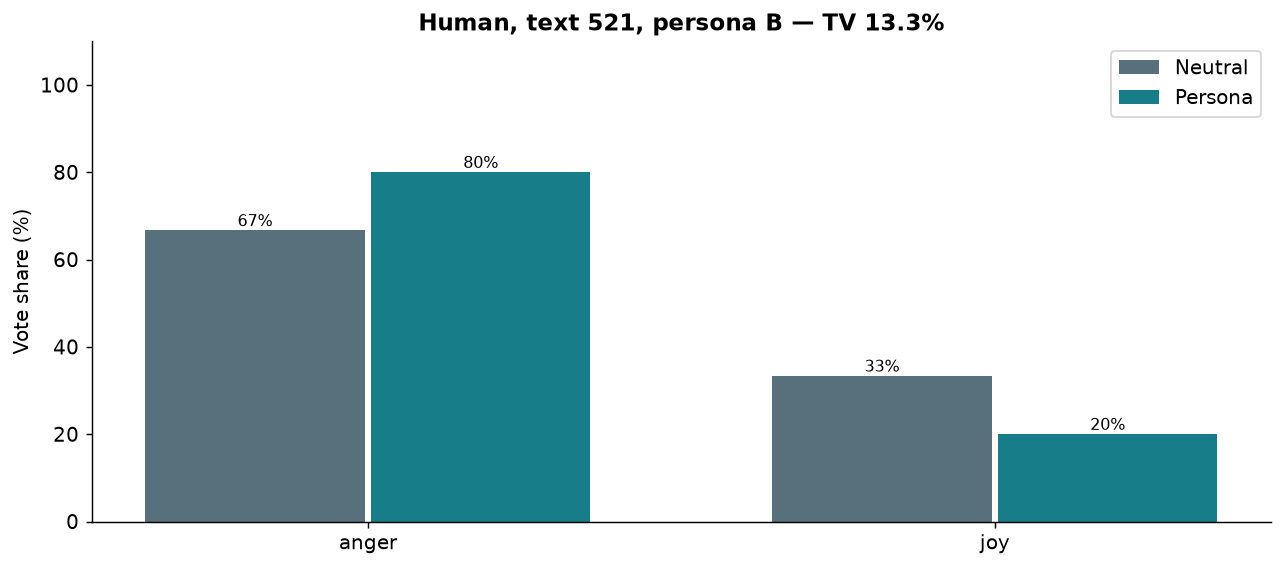

**Text:** A child that I was looking after was refusing to get off the bathroom floor and she needed to go to bed. Whenever I intervened she pushed me away

**Persona:** a grandparent

**Winning label:** anger → anger. **Votes:** 3 → 5. **Emotions added:** none; **removed:** none. This is the example with the largest shift of its kind, chosen to illustrate, not to be typical.

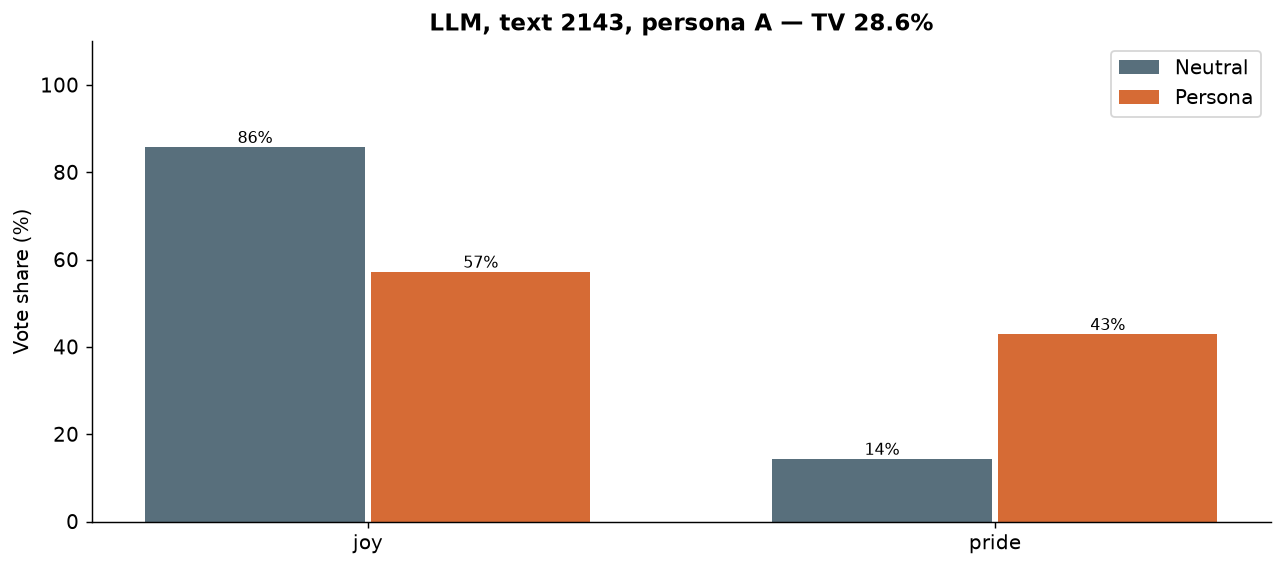

**Text:** I baked a delicious strawberry cobbler.

**Persona:** a home baker

**Winning label:** joy → joy. **Votes:** 7 → 7. **Emotions added:** none; **removed:** none. **Prompt set-up:** few_shot/inline. This is the example with the largest shift of its kind, chosen to illustrate, not to be typical.

**What it means:** the same emotions stay, but the balance changes. For people this is rare; for models it is common, so models often react by re-weighting rather than switching.

In [15]:
rows = []
for src, d in [('Human', study.h), ('LLM', study.l)]:
    for event in ['same_support_change', 'strict_proportion']:
        n = int(d[event].sum())
        rows.append({'source': src, 'definition': event, 'comparisons': n, 'out_of': len(d),
                     'percent': 100 * n / len(d), 'unique_texts': d.loc[d[event], 'text_id'].nunique()})
proportions = pd.DataFrame(rows)
table(proportions, 'proportion_only_definitions', 2)
example(study, 'strict_proportion', 'Human', 'strict_proportions_human')
example(study, 'strict_proportion', 'LLM', 'strict_proportions_llm')
explain('**What it means:** the same emotions stay, but the balance changes. For people this is rare; for '
        'models it is common, so models often react by re-weighting rather than switching.')

## 4. Which emotions appear and disappear?

"Appears" = no votes in the neutral version, some under the persona; "disappears" = the reverse.
Several emotions can do this in one comparison, so the percentages do not add up to 100. This is
about the group's votes: it does not mean an individual person switched emotions.

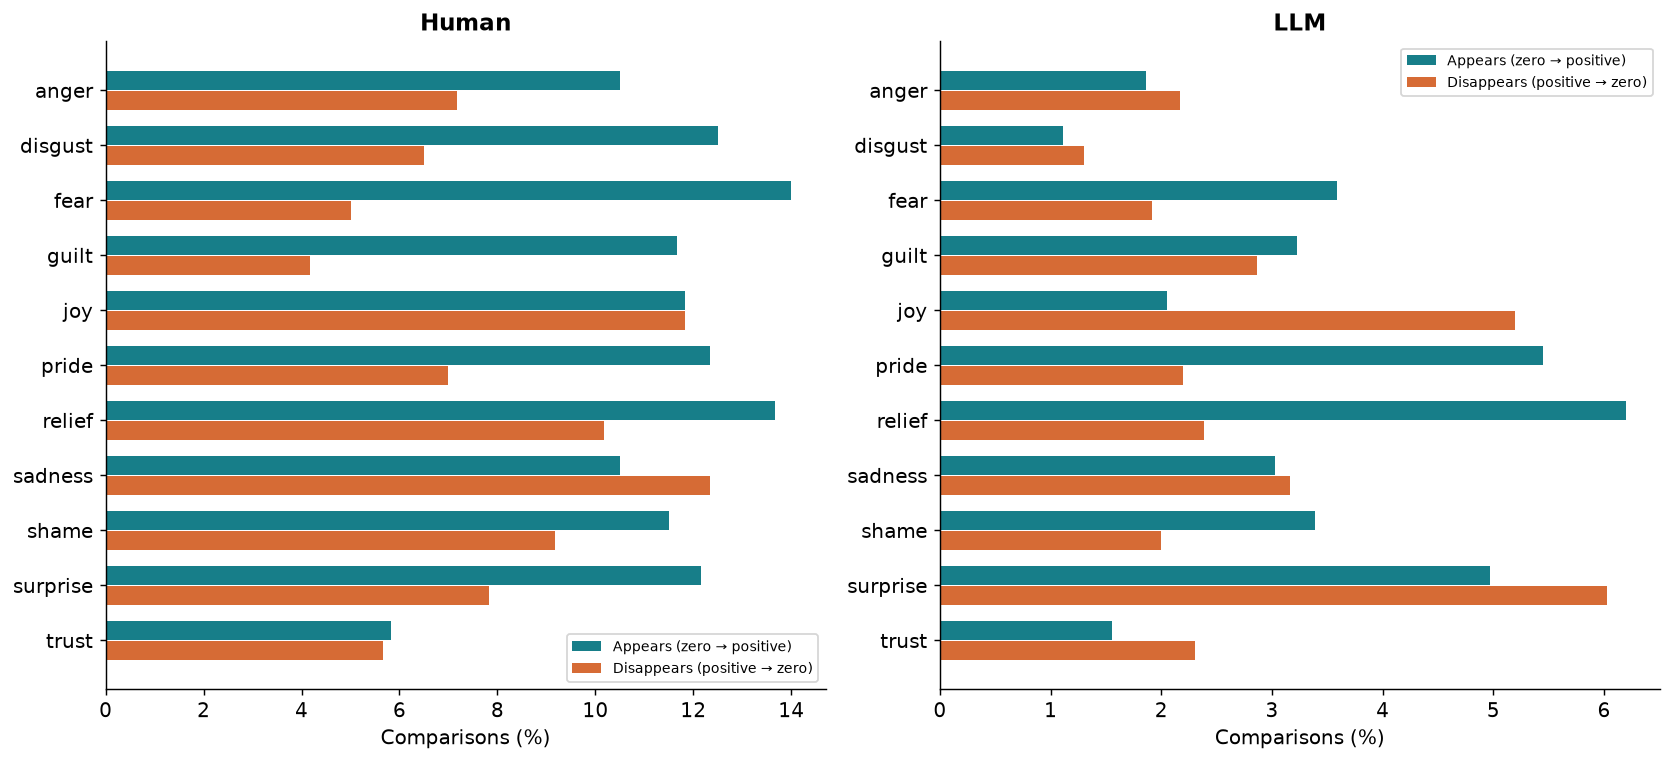

,source,emotion,appears_pct,disappears_pct
0,Human,anger,10.500,7.167
1,Human,disgust,12.500,6.500
2,Human,fear,14.000,5.000
3,Human,guilt,11.667,4.167
4,Human,joy,11.833,11.833
5,Human,pride,12.333,7.000
6,Human,relief,13.667,10.167
7,Human,sadness,10.500,12.333
8,Human,shame,11.500,9.167
9,Human,surprise,12.167,7.833


**Human:** the emotion that appears most often is fear (14.0% of comparisons). This is a description, not a tested result.

**LLM:** the emotion that appears most often is relief (6.2% of comparisons). This is a description, not a tested result.

In [16]:
emotion_event_rates = emotion_events(study)
for src in ['Human', 'LLM']:
    r = emotion_event_rates[emotion_event_rates.source == src].sort_values('appears_pct', ascending=False).iloc[0]
    explain(f'**{src}:** the emotion that appears most often is {r.emotion} ({r.appears_pct:.1f}% of comparisons). '
            'This is a description, not a tested result.')

## 5. Does this depend on the text group?

Share of comparisons where at least one emotion appears, and where at least one disappears, by
group. The error bars resample texts. These describe a pattern; H3 itself was tested in
Notebook 1.

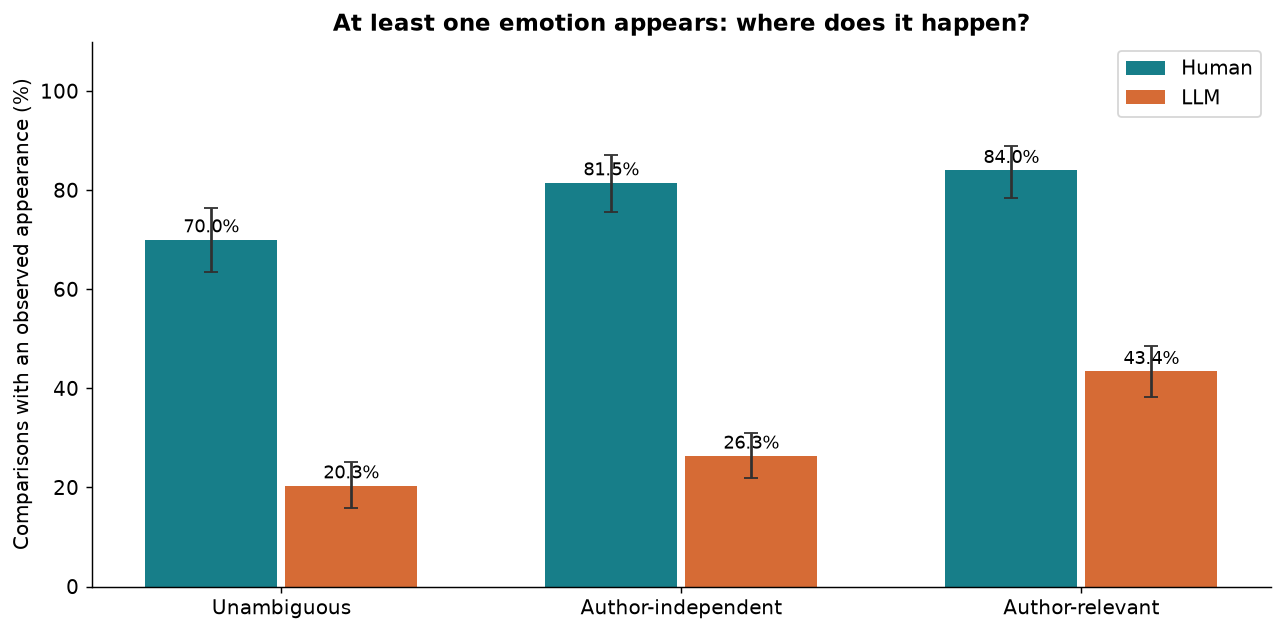

,source,category,comparisons,texts,value_pct,lo_pct,hi_pct
0,Human,author_relevant,200,100,84.000,78.500,89.000
1,Human,author_independent,200,100,81.500,75.500,87.000
2,Human,unambiguous,200,100,70.000,63.500,76.500
3,LLM,author_relevant,1200,100,43.417,38.250,48.500
4,LLM,author_independent,1200,100,26.333,21.833,30.917
5,LLM,unambiguous,1200,100,20.333,15.750,25.167


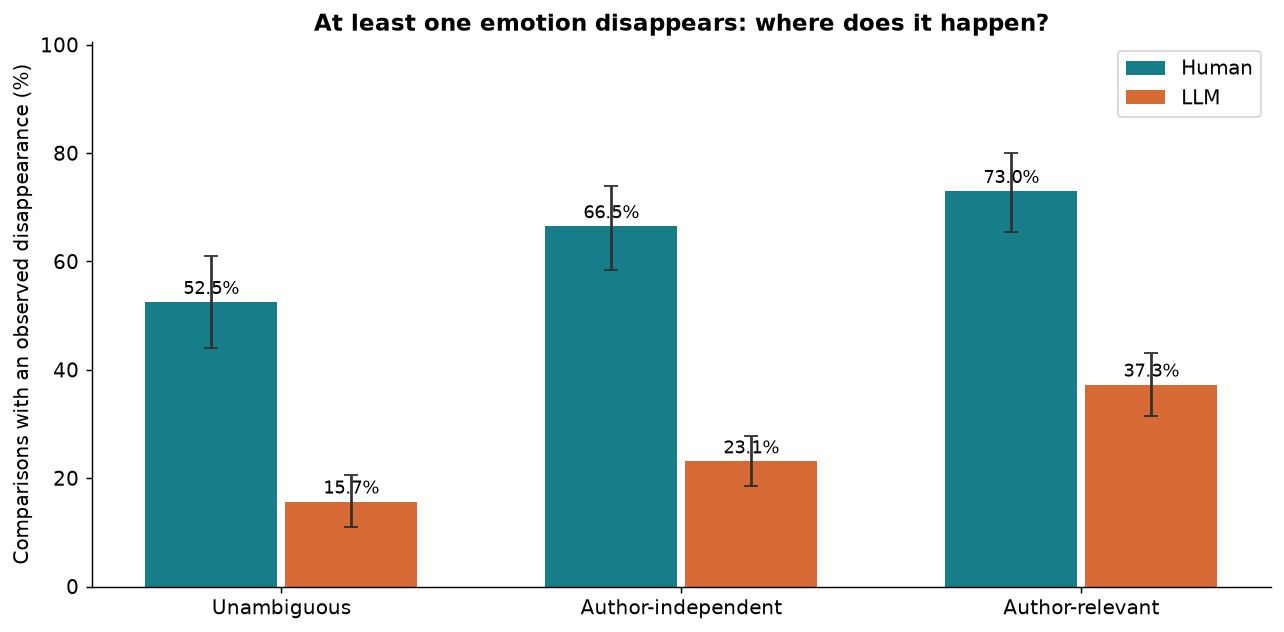

,source,category,comparisons,texts,value_pct,lo_pct,hi_pct
0,Human,author_relevant,200,100,73.000,65.500,80.000
1,Human,author_independent,200,100,66.500,58.500,74.012
2,Human,unambiguous,200,100,52.500,44.000,61.000
3,LLM,author_relevant,1200,100,37.250,31.417,43.167
4,LLM,author_independent,1200,100,23.083,18.583,27.750
5,LLM,unambiguous,1200,100,15.667,11.000,20.667


**Read together:** emotions appear *and* disappear most on author-relevant texts, so the mix of readings changes rather than simply growing. Human rates are higher partly because each version had different raters and only about 3 votes: one different rater is enough to add an emotion.

In [17]:
gains = bar(study, 'gain_any', 'new_emotions_by_category', 'At least one emotion appears: where does it happen?',
            'Comparisons with an observed appearance (%)')
losses = bar(study, 'loss_any', 'lost_emotions_by_category', 'At least one emotion disappears: where does it happen?',
             'Comparisons with an observed disappearance (%)')
explain('**Read together:** emotions appear *and* disappear most on author-relevant texts, so the mix of '
        'readings changes rather than simply growing. Human rates are higher partly because each version had '
        'different raters and only about 3 votes: one different rater is enough to add an emotion.')

## 6. Do people and models show the same kind of change?

Each model comparison is matched with the human comparison for the same text and persona. Rows =
what people did, columns = what models did; each row adds up to 100%. This is descriptive: no
statistical test of agreement is run on this table.

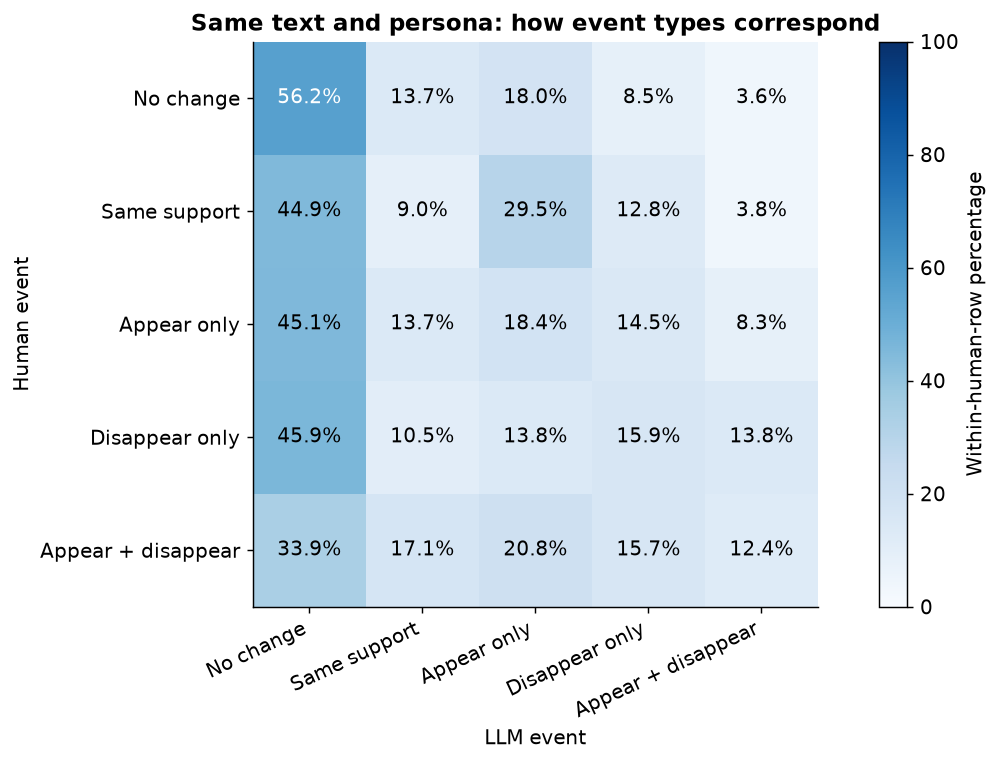

change_llm,change_human,No distribution change,Same emotions; proportions change,Emotions appear only,Emotions disappear only,Emotions appear AND disappear
0,No distribution change,172,42,55,26,11
1,Same emotions; proportions change,35,7,23,10,3
2,Emotions appear only,411,125,168,132,76
3,Emotions disappear only,179,41,54,62,54
4,Emotions appear AND disappear,649,328,399,300,238


,change_human,matched_comparisons
0,No distribution change,306
1,Same emotions; proportions change,78
2,Emotions appear only,912
3,Emotions disappear only,390
4,Emotions appear AND disappear,1914


**What it shows:** whatever people did, the most common model response is "no change". Any correspondence looks weak, and it is not formally tested here.

In [18]:
j = study.l[['text_id', 'side', 'change']].merge(study.h[['text_id', 'side', 'change']], on=['text_id', 'side'],
                                                 suffixes=('_llm', '_human'), validate='many_to_one')
cross = pd.crosstab(j.change_human, j.change_llm).reindex(index=EVENT_TYPES, columns=EVENT_TYPES, fill_value=0)
percent = cross.div(cross.sum(axis=1), axis=0).fillna(0) * 100
short = ['No change', 'Same support', 'Appear only', 'Disappear only', 'Appear + disappear']
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(percent, cmap='Blues', vmin=0, vmax=100)
for i in range(5):
    for k in range(5):
        ax.text(k, i, f'{percent.iloc[i, k]:.1f}%', ha='center', va='center',
                color='white' if percent.iloc[i, k] > 50 else 'black')
ax.set_xticks(range(5), short, rotation=25, ha='right')
ax.set_yticks(range(5), short)
ax.set_xlabel('LLM event')
ax.set_ylabel('Human event')
ax.set_title('Same text and persona: how event types correspond')
fig.colorbar(im, ax=ax, label='Within-human-row percentage')
finish(fig, 'human_model_event_correspondence')
table(cross.reset_index(), 'human_model_event_counts')
table(cross.sum(axis=1).rename('matched_comparisons').reset_index(), 'human_event_denominators')
explain('**What it shows:** whatever people did, the most common model response is "no change". Any '
        'correspondence looks weak, and it is not formally tested here.')

## 7. Which emotions gain or lose share on average?

For each emotion: persona share minus neutral share, averaged per text and then over texts. Red =
gained, blue = lost. Averages can hide opposite shifts that cancel out.

**Tests (exploratory):** for each of the 66 cells (2 sources × 3 groups × 11 emotions), flip the
sign of each text's change at random 10,000 times and see how often the average is at least as far
from zero as the real one. With 66 tests, the Benjamini-Hochberg correction (`bh_fdr`) is applied.

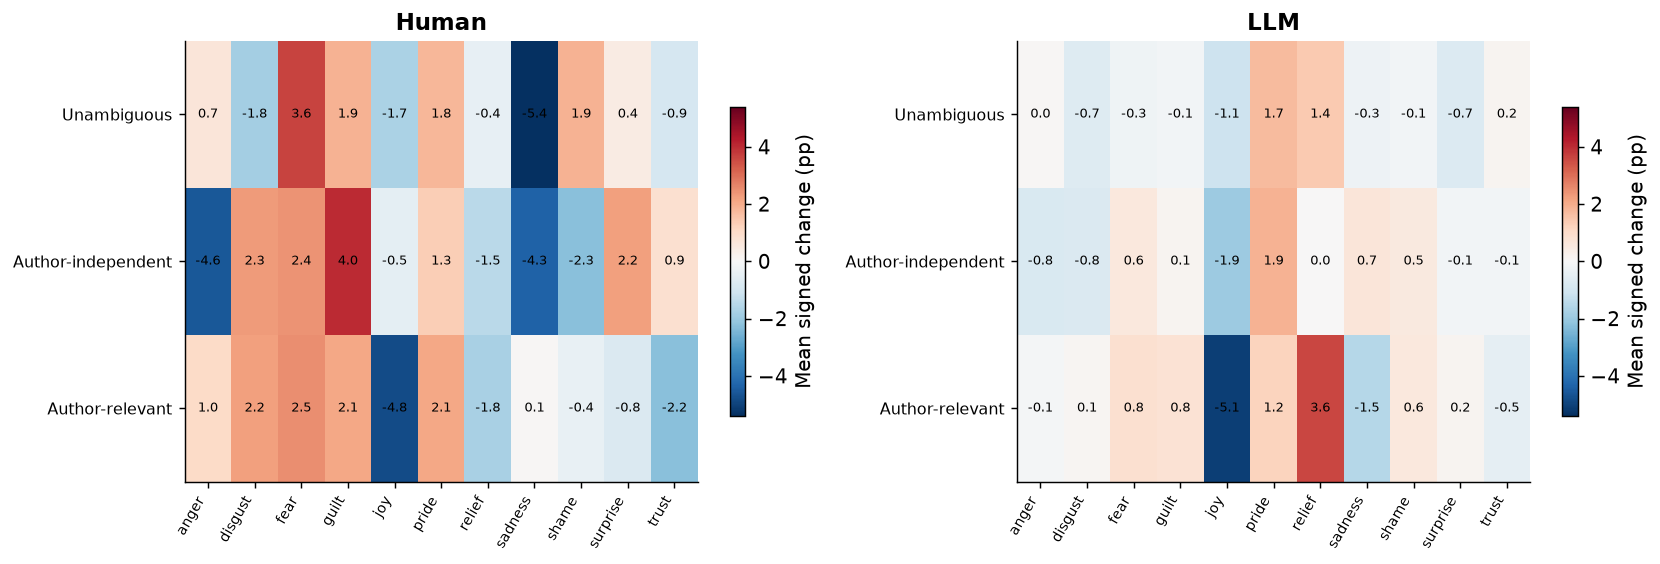

,source,category,emotion,mean_change_pp,p_raw,p_BH
0,Human,Unambiguous,anger,0.6667,0.6932,0.8863
1,Human,Unambiguous,disgust,-1.8333,0.3025,0.5749
2,Human,Unambiguous,fear,3.6417,0.0398,0.2574
3,Human,Unambiguous,guilt,1.8667,0.07559,0.3118
4,Human,Unambiguous,joy,-1.7083,0.3601,0.6093
...,...,...,...,...,...,...
61,LLM,Author-relevant,relief,3.5885,0.0008999,0.01188
62,LLM,Author-relevant,sadness,-1.5480,0.1372,0.3749
63,LLM,Author-relevant,shame,0.5605,0.2677,0.5353
64,LLM,Author-relevant,surprise,0.1683,0.8935,0.9508


**Tests:** 7 of 66 changes are significant after correction: Human author-independent guilt +4.0; LLM unambiguous disgust -0.7; LLM unambiguous pride +1.7; LLM author-independent joy -1.9; LLM author-independent pride +1.9; LLM author-relevant joy -5.1; LLM author-relevant relief +3.6. The rest are too small to confirm. These are exploratory tests.

In [19]:
emotion_rows = []
for src, d in [('Human', study.h), ('LLM', study.l)]:
    expanded = pd.DataFrame(np.stack(d.delta), columns=E)
    expanded['text_id'] = d.text_id.to_numpy()
    expanded['category'] = d.category.to_numpy()
    t = expanded.groupby(['text_id', 'category'])[E].mean().reset_index()
    for cat in CATS:
        vals = t.loc[t.category == cat, E].to_numpy()
        rng = np.random.default_rng(808)
        null = rng.choice([-1, 1], size=(N_RANDOM, len(vals))) @ vals / len(vals)
        for k, e in enumerate(E):
            obs = vals[:, k].mean()
            p = (1 + (np.abs(null[:, k]) >= abs(obs) - 1e-12).sum()) / (N_RANDOM + 1)
            emotion_rows.append({'source': src, 'category': CAT_NAME[cat], 'emotion': e,
                                 'mean_change_pp': 100 * obs, 'p_raw': p})
emotion_tests = pd.DataFrame(emotion_rows)
emotion_tests['p_BH'] = bh_fdr(emotion_tests.p_raw)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
limit = max(abs(emotion_tests.mean_change_pp).max(), 1)
for ax, src in zip(axes, ['Human', 'LLM']):
    grid = emotion_tests[emotion_tests.source == src].pivot(index='category', columns='emotion',
                                                           values='mean_change_pp').reindex(index=CAT_NAMES, columns=E)
    im = ax.imshow(grid, cmap='RdBu_r', vmin=-limit, vmax=limit, aspect='auto')
    ax.set_xticks(range(11), E, rotation=60, ha='right', fontsize=8)
    ax.set_yticks(range(3), CAT_NAMES, fontsize=9)
    ax.set_title(src)
    for i in range(3):
        for k in range(11):
            ax.text(k, i, f'{grid.iloc[i, k]:.1f}', ha='center', va='center', fontsize=7)
    fig.colorbar(im, ax=ax, label='Mean signed change (pp)', shrink=.7)
finish(fig, 'emotion_share_changes')
table(emotion_tests, 'exploratory_per_emotion_tests', 4)
significant = emotion_tests[emotion_tests.p_BH < .05]
explain(f'**Tests:** {len(significant)} of 66 changes are significant after correction: '
        + '; '.join(f'{r.source} {r.category.lower()} {r.emotion} {r.mean_change_pp:+.1f}'
                    for _, r in significant.iterrows())
        + '. The rest are too small to confirm. These are exploratory tests.')

## 8. Do the votes spread out, and does the number of votes matter?

**Spread (entropy):** higher = votes spread over more emotions. It is not the same as how far the
votes moved.

**Equal vote counts:** people have about 3 votes per version and models up to 7, and fewer votes
can make shifts look bigger. So both sides are cut to **3 votes**: 3 random human votes per version,
and the **same 3 random models** on both sides of a model comparison, repeated 200 times. This
checks whether unequal counts could explain the gap. It cannot turn the human design (different
people per version) into the model design (same model on both versions).

,source,quantity,mean,ci_lo,ci_hi
0,Human,tv_raw,0.5315,0.5060,0.5574
1,Human,tv_standardised,0.5324,0.5069,0.5582
2,Human,entropy_raw,0.1769,0.1288,0.2250
3,Human,entropy_standardised,0.1348,0.0890,0.1808
4,LLM,tv_raw,0.1829,0.1651,0.2015
5,LLM,tv_standardised,0.1987,0.1797,0.2181
6,LLM,entropy_raw,0.0202,-0.0020,0.0424
7,LLM,entropy_standardised,0.0133,-0.0026,0.0291


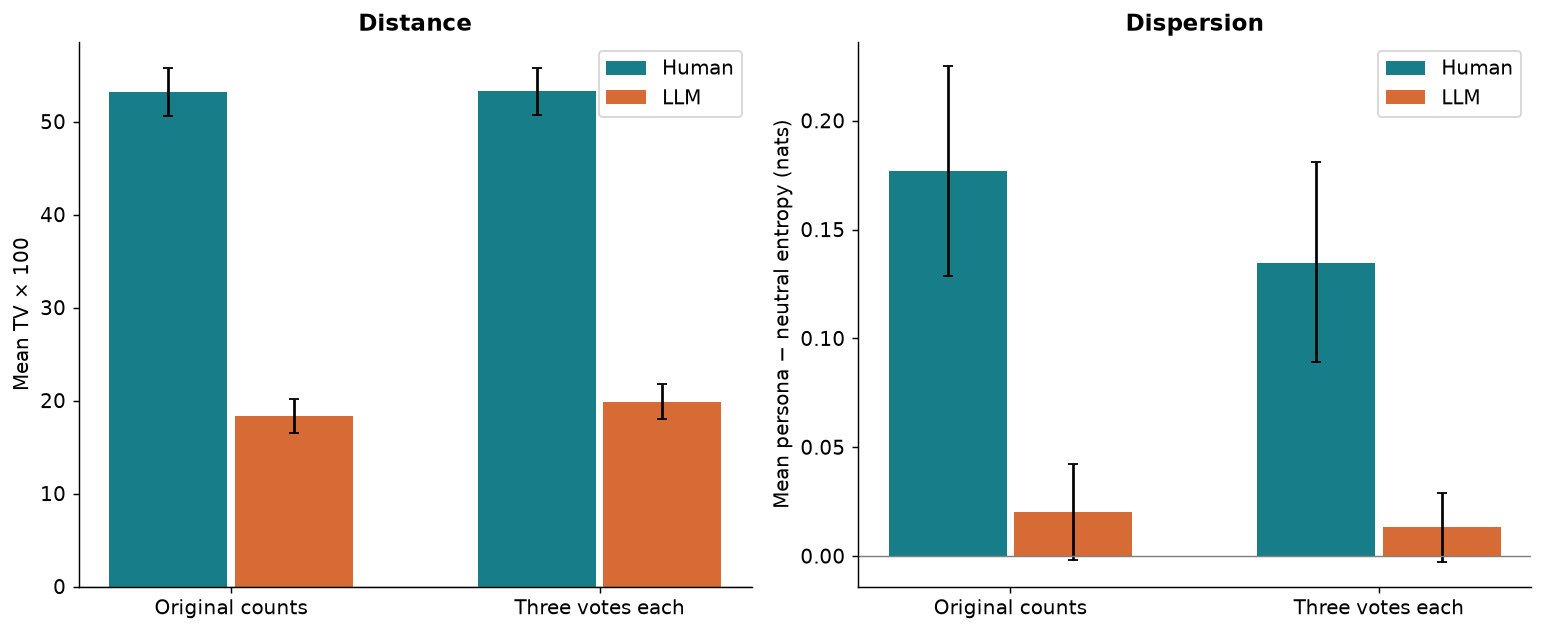

,analysis,mean_gap_pp,ci_lo,ci_hi
0,tv_raw,34.860,32.245,37.496
1,tv_standardised,33.371,30.786,36.034


**Size:** the human−model gap is 34.86 points with the original counts and about 33 points with 3 votes each, so unequal vote counts do not plausibly explain it. This check does not identify what causes the gap. **Spread:** human votes spread out under a persona with both counts; for models the error bar touches zero, so no increase in spread is detected.

In [20]:
standardised, standardised_summary = count_sensitivity(study)
table(standardised_summary, 'count_standardisation_summary', 4)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, quantity, scale, ylabel in [(axes[0], 'tv', 100, 'Mean TV × 100'),
                                    (axes[1], 'entropy', 1, 'Mean persona − neutral entropy (nats)')]:
    for j, src in enumerate(['Human', 'LLM']):
        q = standardised_summary[standardised_summary.source == src].set_index('quantity').loc[
            [quantity + '_raw', quantity + '_standardised']]
        x = np.arange(2) + (j - .5) * .34
        ax.bar(x, q['mean'] * scale, .32, label=src, color=COLORS[src])
        ax.errorbar(x, q['mean'] * scale, yerr=[(q['mean'] - q.ci_lo) * scale, (q.ci_hi - q['mean']) * scale],
                    fmt='none', color='black', capsize=3)
    ax.set_xticks([0, 1], ['Original counts', 'Three votes each'])
    ax.set_ylabel(ylabel)
    ax.axhline(0, color='grey', lw=.8)
    ax.legend()
    ax.set_title('Distance' if quantity == 'tv' else 'Dispersion')
finish(fig, 'count_standardisation_TV_entropy')
per_text = standardised.groupby(['source', 'text_id'])[['tv_raw', 'tv_standardised']].mean().unstack('source')
gap_rows = []
for quantity in ['tv_raw', 'tv_standardised']:
    p, lo, hi = boot_mean(per_text[quantity]['Human'] - per_text[quantity]['LLM'])
    gap_rows.append({'analysis': quantity, 'mean_gap_pp': 100 * p, 'ci_lo': 100 * lo, 'ci_hi': 100 * hi})
gap = pd.DataFrame(gap_rows)
table(gap, 'count_standardised_magnitude_gap', 3)
explain(f'**Size:** the human−model gap is {gap.iloc[0].mean_gap_pp:.2f} points with the original counts and about '
        f'{gap.iloc[1].mean_gap_pp:.0f} points with 3 votes each, so unequal vote counts do not plausibly explain it. '
        'This check does not identify what causes the gap. **Spread:** human votes spread out under a persona '
        'with both counts; for models the error bar touches zero, so no increase in spread is detected.')

## 9. Does every model change its answers?

Each model gave one answer per version. This counts how often a model's own two answers differ
(only where both are valid). It is separate from the ensemble test in Notebook 1, which picks up
changes several models share.

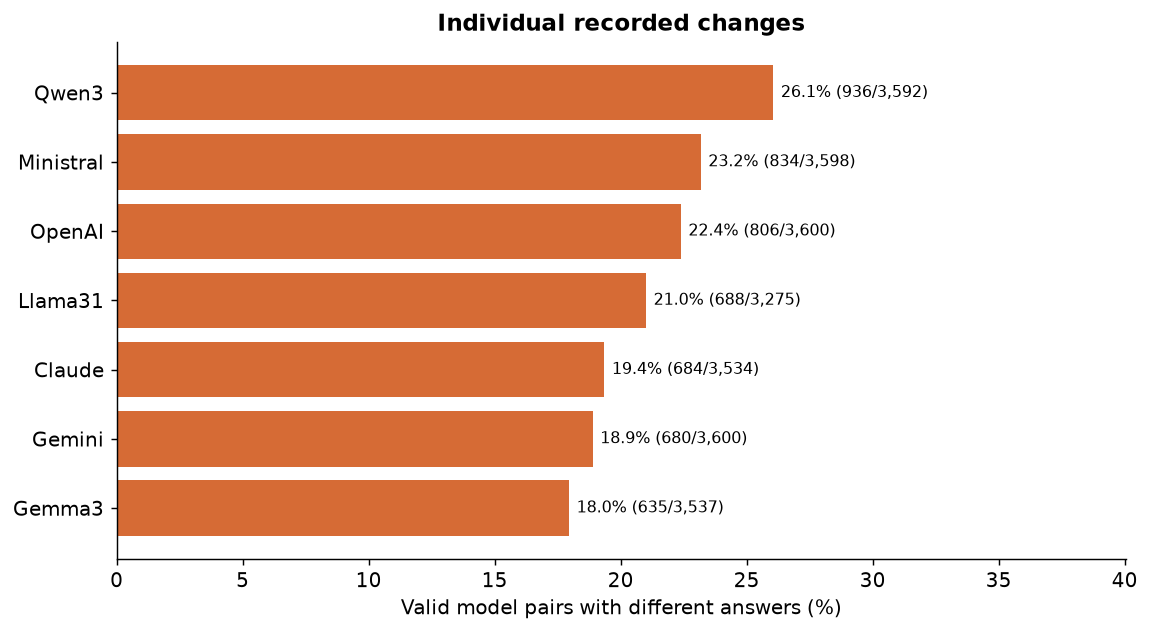

,model,valid_pairs,changed_pairs,change_rate,change_pct
0,Gemma3,3537,635,0.18,17.95
1,Gemini,3600,680,0.19,18.89
2,Claude,3534,684,0.19,19.35
3,Llama31,3275,688,0.21,21.01
4,OpenAI,3600,806,0.22,22.39
5,Ministral,3598,834,0.23,23.18
6,Qwen3,3592,936,0.26,26.06


,discordant_models,comparisons
0,0,1365
1,1,838
2,2,576
3,3,380
4,4,210
5,5,126
6,6,72
7,7,33


**What it shows:** 5,263 of 24,736 model answer pairs changed. In 61.2% of comparisons at most one model changed; those cannot count as evidence in the ensemble test, which is why these individual rates are shown too. They are descriptive: no test compared the models, so no model is shown to be more sensitive than another.

In [21]:
ind = study.individual.groupby('model').agg(valid_pairs=('changed', 'size'), changed_pairs=('changed', 'sum'),
                                             change_rate=('changed', 'mean')).sort_values('change_rate')
ind['change_pct'] = 100 * ind.change_rate
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(ind.index, ind.change_pct, color='#d66b35')
for i, (_, r) in enumerate(ind.iterrows()):
    ax.text(r.change_pct + .3, i, f'{r.change_pct:.1f}% ({int(r.changed_pairs):,}/{int(r.valid_pairs):,})',
            va='center', fontsize=9)
ax.set_xlim(0, ind.change_pct.max() + 14)
ax.set_xlabel('Valid model pairs with different answers (%)')
ax.set_title('Individual recorded changes')
finish(fig, 'individual_model_changes')
table(ind.reset_index(), 'individual_model_change_rates', 2)
changed = study.individual.groupby(['text_id', 'side', 'config']).changed.sum()
coordination = pd.DataFrame({'discordant_models': changed.value_counts().sort_index().index,
                             'comparisons': changed.value_counts().sort_index().values})
table(coordination, 'ensemble_discordance_counts')
explain(f'**What it shows:** {study.individual.changed.sum():,} of {len(study.individual):,} model answer pairs '
        f'changed. In {(changed <= 1).mean() * 100:.1f}% of comparisons at most one model changed; those cannot '
        'count as evidence in the ensemble test, which is why these individual rates are shown too. They are '
        'descriptive: no test compared the models, so no model is shown to be more sensitive than another.')

## 10. Does the prompt set-up matter?

For each text and prompt set-up, average the two persona comparisons. The Friedman test
(`prompt_test`) ranks the 6 set-ups within each text; if the set-up did not matter, all would get
similar average ranks. Left: old method; right: vector method.

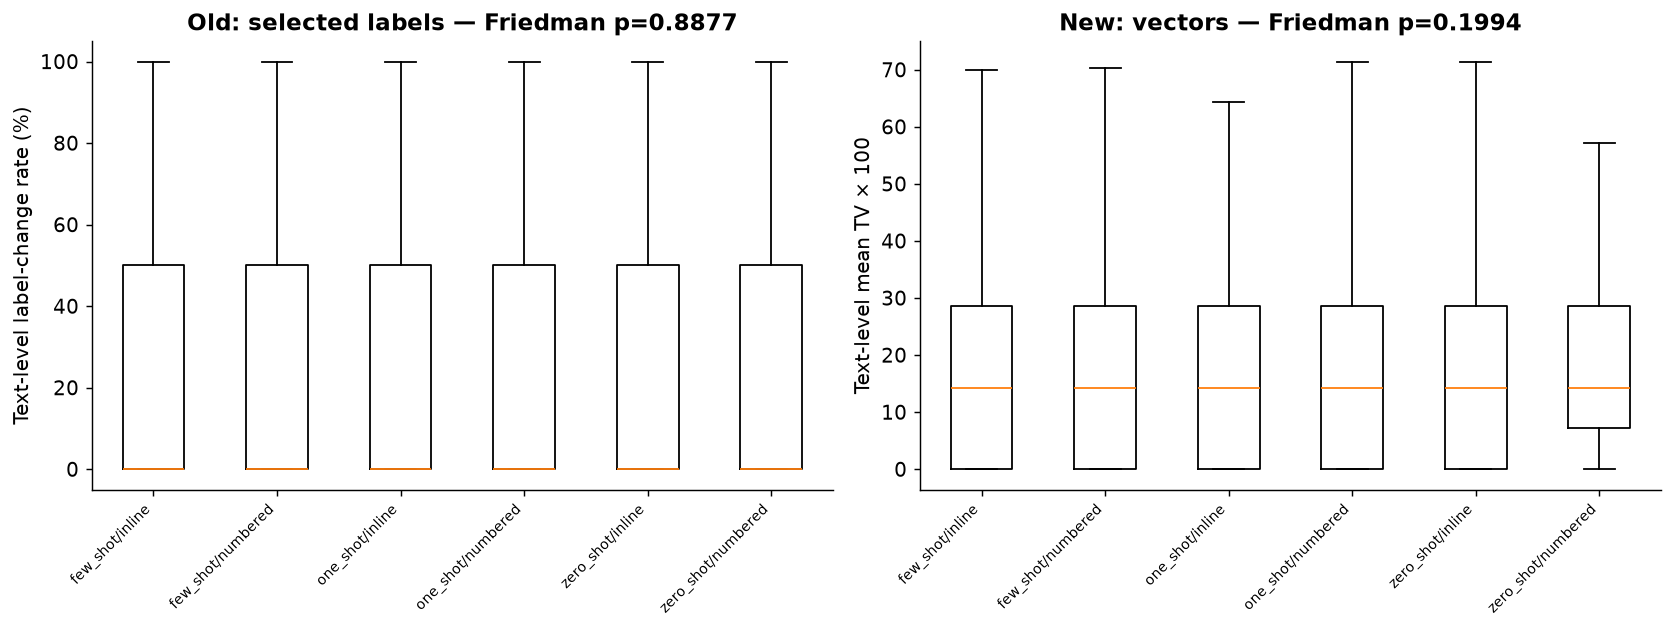

,metric,texts,configurations,friedman_stat,p_value
0,flip,300,6,1.709,0.8877
1,tv,300,6,7.298,0.1994


**What it means:** no statistically detectable difference between the six set-ups, so the model effect does not appear to depend on one prompt. "Not detected" does not prove the set-ups are identical.

In [22]:
prompt_results = []
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ['flip', 'tv']):
    values, result = prompt_test(study, metric)
    prompt_results.append(result)
    groups = [values[c].to_numpy() * 100 for c in values]
    ax.boxplot(groups, showfliers=False)
    ax.set_xticks(range(1, 7), values.columns, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Text-level label-change rate (%)' if metric == 'flip' else 'Text-level mean TV × 100')
    ax.set_title(('Old: selected labels' if metric == 'flip' else 'New: vectors') + f' — Friedman p={result.iloc[0].p_value:.4f}')
finish(fig, 'prompt_old_and_vector')
table(pd.concat(prompt_results, ignore_index=True), 'prompt_comparison_tests')
explain('**What it means:** no statistically detectable difference between the six set-ups, so the model effect '
        'does not appear to depend on one prompt. "Not detected" does not prove the set-ups are identical.')

## 11. Is it the specific persona, or just naming any author? (models only)

Three steps: neutral → "written by a person" (generic), generic → specific persona, and neutral →
persona. To keep the three comparable, only models valid in **all three** versions are used.
The three distances **do not add up**, so they are not parts of one total.

,side,contrast,metric,mean_pct,ci_lo,ci_hi,cells,min_common_models
0,a,Generic → persona,flip,15.72,12.61,18.94,1800,4
1,a,Generic → persona,tv,16.20,14.14,18.33,1800,4
2,a,Neutral → generic,flip,7.94,6.22,9.78,1800,4
3,a,Neutral → generic,tv,7.98,7.23,8.75,1800,4
4,a,Neutral → persona,flip,15.83,12.61,19.17,1800,4
5,a,Neutral → persona,tv,16.73,14.68,18.89,1800,4
6,b,Generic → persona,flip,19.83,16.44,23.39,1800,4
7,b,Generic → persona,tv,19.30,17.01,21.61,1800,4
8,b,Neutral → generic,flip,7.94,6.17,9.83,1800,4
9,b,Neutral → generic,tv,8.01,7.26,8.77,1800,4


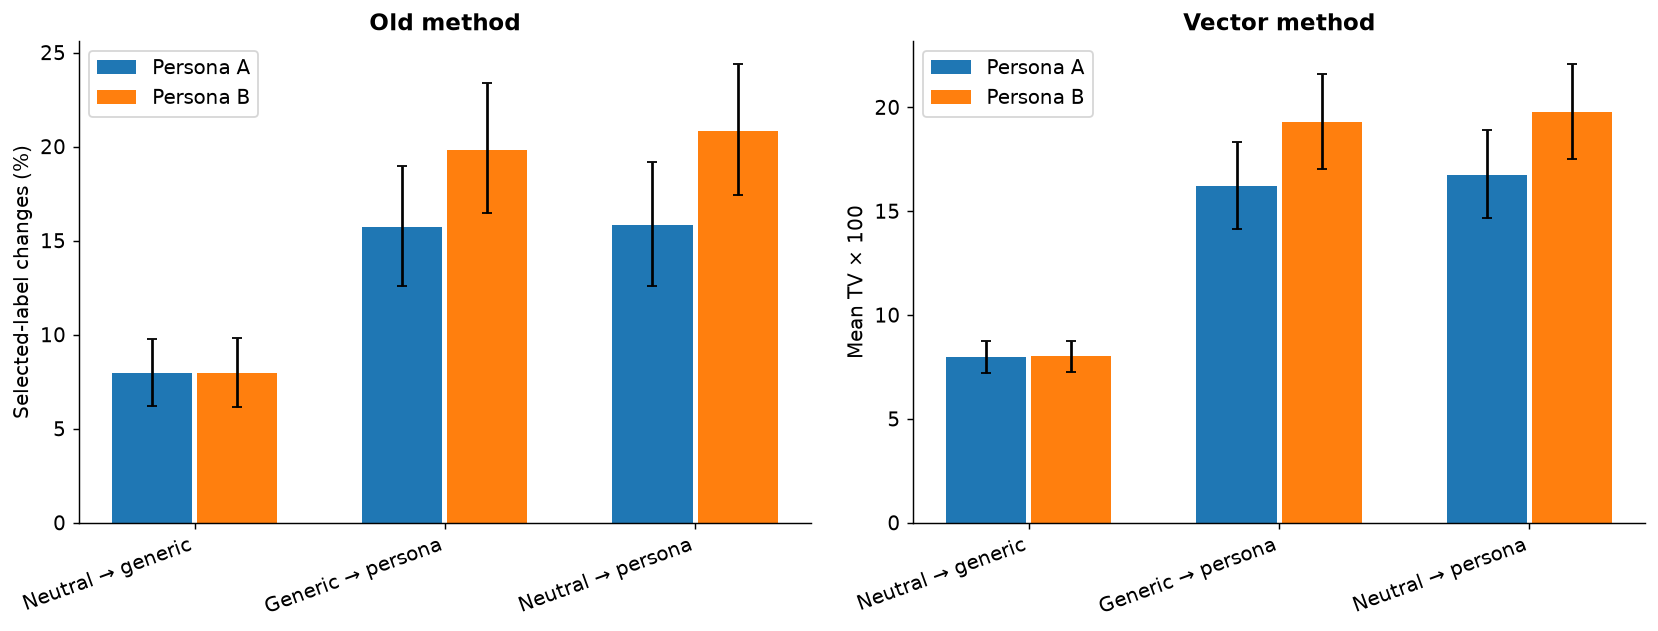

**What it means:** a generic author line is associated with a small shift; going from the generic author to a specific persona is associated with a shift about twice as large. So models are sensitive to *who* the author is, not only to *whether* one is named. The distances are associations, not parts of a total.

In [23]:
control = []
for tid in study.ids:
    for side in ['a', 'b']:
        for pv, lf in study.configs:
            n = study.mvotes[(tid, 'neutral', pv, lf)]
            g = study.mvotes[(tid, 'generic_human', pv, lf)]
            p = study.mvotes[(tid, 'persona_' + side, pv, lf)]
            common = sorted(n.keys() & g.keys() & p.keys())
            assert len(common) >= 3
            for label, a, b in [('Neutral → generic', n, g), ('Generic → persona', g, p), ('Neutral → persona', n, p)]:
                pa = vec([a[m] for m in common])
                pb = vec([b[m] for m in common])
                control.append({'text_id': tid, 'side': side, 'config': pv + '/' + lf, 'contrast': label,
                                'n_models': len(common), 'flip': int(pa.argmax() != pb.argmax()),
                                'tv': abs(pa - pb).sum() / 2})
control = pd.DataFrame(control)
rows = []
for (side, contrast), q in control.groupby(['side', 'contrast']):
    for metric in ['flip', 'tv']:
        point, lo, hi = boot_mean(q.groupby('text_id')[metric].mean())
        rows.append({'side': side, 'contrast': contrast, 'metric': metric, 'mean_pct': 100 * point,
                     'ci_lo': 100 * lo, 'ci_hi': 100 * hi, 'cells': len(q), 'min_common_models': q.n_models.min()})
control_summary = pd.DataFrame(rows)
table(control_summary, 'generic_author_three_way_control', 2)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order = ['Neutral → generic', 'Generic → persona', 'Neutral → persona']
for ax, metric in zip(axes, ['flip', 'tv']):
    for j, side in enumerate(['a', 'b']):
        q = control_summary[(control_summary.side == side) & (control_summary.metric == metric)].set_index('contrast').reindex(order)
        x = np.arange(3) + (j - .5) * .34
        ax.bar(x, q.mean_pct, .32, label='Persona ' + side.upper())
        ax.errorbar(x, q.mean_pct, yerr=[q.mean_pct - q.ci_lo, q.ci_hi - q.mean_pct], fmt='none', color='black', capsize=3)
    ax.set_xticks(range(3), order, rotation=20, ha='right')
    ax.set_ylabel('Selected-label changes (%)' if metric == 'flip' else 'Mean TV × 100')
    ax.set_title('Old method' if metric == 'flip' else 'Vector method')
    ax.legend()
finish(fig, 'generic_author_control_comparison')
explain('**What it means:** a generic author line is associated with a small shift; going from the generic author '
        'to a specific persona is associated with a shift about twice as large. So models are sensitive to *who* '
        'the author is, not only to *whether* one is named. The distances are associations, not parts of a total.')

## 12. Does the old method's H3 result change when chance is allowed for?

The same sensitivity check as Notebook 1 C6, applied to the old label-change measure.

In [24]:
old_sensitivity, _ = test_h3(study, 'flip')
table(old_sensitivity, 'old_H3_conditional_reference_sensitivity')
explain('**What it means:** the old method is also affected by chance variation. Neither the raw nor the '
        'adjusted old-method comparison shows author-relevant texts changing more than author-independent ones.')

,analysis,contrast,difference_pp,ci_lo,ci_hi,p_raw,p_holm
0,Raw,Author-relevant minus Author-independent,4.500,-6.000,15.000,0.4721,0.4721
1,Raw,Author-independent minus Unambiguous,18.500,7.000,29.500,0.002,0.004
2,Raw,Author-relevant minus Unambiguous,23.000,12.000,34.000,9.999e-05,0.0003
3,Conditional-null referenced,Author-relevant minus Author-independent,-4.094,-10.994,2.833,0.2417,0.4834
4,Conditional-null referenced,Author-independent minus Unambiguous,5.308,-0.860,11.393,0.09279,0.2784
5,Conditional-null referenced,Author-relevant minus Unambiguous,1.214,-5.359,7.670,0.7151,0.7151


**What it means:** the old method is also affected by chance variation. Neither the raw nor the adjusted old-method comparison shows author-relevant texts changing more than author-independent ones.

## 13. What these data are, and what this notebook adds

The data are **vote distributions under different author framings**. Human vectors summarise
different readers; model vectors summarise different systems. They are not repeated measurements of
one person's feelings, and the model ensemble is not one model's probabilities.

This notebook separates:
- a change of the winning label, and a change of the full set of tied winners;
- the same emotions with new percentages;
- emotions appearing and disappearing;
- how far and in which direction the votes move;
- spread, prompt set-ups and individual models;
- raw differences and what remains after allowing for chance.

**In one sentence:** a winning label only tells you the winner; keeping all the votes shows where
they go, which reveals changes the label hides and also shows where a result is not robust.

**What these notebooks do not do:** they do not recover who rated what, invent repeated model
answers, split the generic-author control into additive parts, or guarantee that every hypothesis
holds.